In [1]:
# ===============================
# Core Python Libraries
# ===============================
import os
import pickle
import joblib
import numpy as np
import pandas as pd
from collections import Counter
from scipy.special import expit  # sigmoid

# ===============================
# Data Visualization
# ===============================
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# ===============================
# NLP: NLTK 
# ===============================
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.util import ngrams

# ===============================
# Scikit-learn: Preprocessing, Models, Metrics
# ===============================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import SGDClassifier, PassiveAggressiveClassifier

# ===============================
# NGBoost
# ===============================
from ngboost import NGBClassifier
from ngboost.distns import Bernoulli

# ===============================
# TensorFlow / Keras
# ===============================
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import Dense, Input, Embedding, Conv1D, GlobalMaxPooling1D, LSTM, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# ===============================
# Transformers (Hugging Face)
# ===============================
from transformers import (
    AutoTokenizer, AutoModel,
    RobertaTokenizer, RobertaModel,
    BertTokenizer, BertForSequenceClassification,
    XLNetTokenizer, XLNetForSequenceClassification
)
import torch
from torch.optim import AdamW

# ===============================
# Custom Modules
# ===============================
from metrics_calculator import MetricsCalculator
from graphs import GraphPlotter
MODEL_DIR = "model"
os.makedirs(MODEL_DIR, exist_ok=True)

In [2]:
import nltk

# Tokenizer
nltk.download('punkt', quiet=True)

# Stopwords
nltk.download('stopwords', quiet=True)

# WordNet for lemmatizer
nltk.download('wordnet', quiet=True)

#  POS tagging for better lemmatization
nltk.download('averaged_perceptron_tagger', quiet=True)


True

In [3]:
labels = ["non-severe","severe"]
metrics_calculator = MetricsCalculator(labels) # Assign Labels to 

In [ ]:
def upload_dataset(file_path):
    """Load the dataset from a CSV file"""
    df = pd.read_csv(file_path,)
    return df

In [5]:
path=r"Dataset.csv"

In [6]:
df= upload_dataset(path)
df

,Short Descritpion,Severity
0,crash on exit after reloading a pgae,non-severe
1,User's interface not working due to bug,non-severe
2,Lack of interoperability in IOT devices,severe
3,low-level network protocols for embedded devices,non-severe
4,memory management bug,severe
...,...,...
102,software code might impact the reliability or ...,severe
103,device freezes or system crashes.,severe
104,modified protocol of TPS was used without ver...,severe
105,Ambiguity on drugs name or patient records,non-severe


In [7]:
def preprocess_data(df, save_path=None, target_col=None):
    """
    Preprocess text columns, combine into a single list of text samples (X_text),
    append non-text features, and encode Y (if target_col is given).

    Parameters:
        df (pd.DataFrame): Input data.
        save_path (str or None): Path to save/load preprocessed CSV. If None, skip file I/O.
        target_col (str or None): Target label column to encode.

    Returns:
        X (list of str + numerical features), Y (label encoded or None)
    """
    global le
    if save_path and os.path.exists(save_path):
        print(f"Loading existing preprocessed file: {save_path}")
        df = pd.read_csv(save_path)
    else:
        print("Preprocessing data" + (f" and saving to: {save_path}" if save_path else " (no saving)"))
        lemmatizer = WordNetLemmatizer()
        stop_words = set(stopwords.words('english'))

        def clean_text(text):
            text = str(text).lower()
            tokens = word_tokenize(text)
            tokens = [lemmatizer.lemmatize(t) for t in tokens if t.isalnum() and t not in stop_words]
            return ' '.join(tokens)

        # Separate target column
        target_series = None
        if target_col and target_col in df.columns:
            target_series = df[target_col]
            df = df.drop(columns=[target_col])

        # Process text columns
        text_columns = df.select_dtypes(include='object').columns
        for col in text_columns:
            df[f'processed_{col}'] = df[col].apply(clean_text)

        # Drop original text columns
        df.drop(columns=text_columns, inplace=True)

        # Reattach target column if it was dropped
        if target_series is not None:
            df[target_col] = target_series

        # Save only if path is specified
        if save_path:
            df.to_csv(save_path, index=False)

    # Select processed and numerical columns
    processed_text_cols = [col for col in df.columns if col.startswith('processed_')]
    non_text_cols = [col for col in df.columns if col not in processed_text_cols + ([target_col] if target_col else [])]

    # Join text columns into a single string
    X_text = df[processed_text_cols].astype(str).agg(' '.join, axis=1)

    # Numeric features
    X_numeric = df[non_text_cols].values if non_text_cols else None

    # Combine text and numeric
    if X_numeric is not None and len(X_numeric) > 0:
        X = [f"{text} {' '.join(map(str, numeric))}" for text, numeric in zip(X_text, X_numeric)]
    else:
        X = X_text.tolist()

    # Label encode target
    Y = None
    if target_col and target_col in df.columns:
        le = LabelEncoder()
        Y = le.fit_transform(df[target_col])

    return X, Y

In [8]:
X, Y = preprocess_data(df, save_path="model/preprocessed_data.csv", target_col="Severity")

Loading existing preprocessed file: model/preprocessed_data.csv


In [9]:
def eda_nlp_analysis(X_text, num_words=100, top_n_words=20):
    """
    Perform NLP EDA:
        1. WordCloud
        2. Top N words
        3. Document length histogram
        4. POS tag frequency
        5. Bigram frequency

    Parameters:
        X_text (list of str): Input preprocessed text data.
        num_words (int): Number of words to show in word cloud.
        top_n_words (int): Number of top frequent words to plot.
    """
    print("Generating NLP EDA Visualizations...")

    # Flatten all tokens from all texts
    all_tokens = [word for doc in X_text for word in word_tokenize(doc)]

    # --- 1. WordCloud ---
    word_freq = Counter(all_tokens)
    wc = WordCloud(width=800, height=400, max_words=num_words, background_color='white').generate_from_frequencies(word_freq)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Top {num_words} Words - WordCloud")
    plt.show()

    # --- 2. Top-N Frequent Words ---
    common_words = word_freq.most_common(top_n_words)
    words, counts = zip(*common_words)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(counts), y=list(words), palette="viridis")
    plt.title(f"Top {top_n_words} Most Frequent Words")
    plt.xlabel("Count")
    plt.ylabel("Word")
    plt.show()

    # --- 3. Document Length Histogram ---
    doc_lengths = [len(word_tokenize(doc)) for doc in X_text]
    plt.figure(figsize=(10, 5))
    sns.histplot(doc_lengths, bins=20, kde=True, color='teal')
    plt.title("Distribution of Document Lengths (in words)")
    plt.xlabel("Number of Words per Document")
    plt.ylabel("Frequency")
    plt.show()

    # --- 4. POS Tag Frequency ---
    all_pos = [tag for _, tag in pos_tag(all_tokens)]
    pos_counts = Counter(all_pos).most_common()
    pos_tags, pos_freqs = zip(*pos_counts)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(pos_tags), y=list(pos_freqs), palette="coolwarm")
    plt.title("Part of Speech (POS) Tag Frequency")
    plt.xlabel("POS Tag")
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)
    plt.show()

    # --- 5. Bigram Frequency Plot ---
    bigrams = list(ngrams(all_tokens, 2))
    bigram_freq = Counter(bigrams).most_common(top_n_words)
    bigram_labels = [' '.join(b) for b, _ in bigram_freq]
    bigram_counts = [count for _, count in bigram_freq]

    plt.figure(figsize=(10, 5))
    sns.barplot(x=bigram_counts, y=bigram_labels, palette="magma")
    plt.title(f"Top {top_n_words} Bigrams")
    plt.xlabel("Count")
    plt.ylabel("Bigram")
    plt.show()


Generating NLP EDA Visualizations...


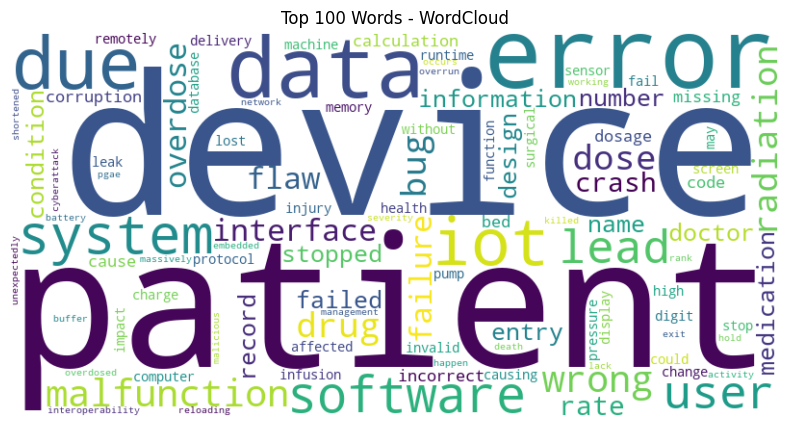

C:\Users\dell\AppData\Local\Temp\ipykernel_16368\1063056502.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette="viridis")


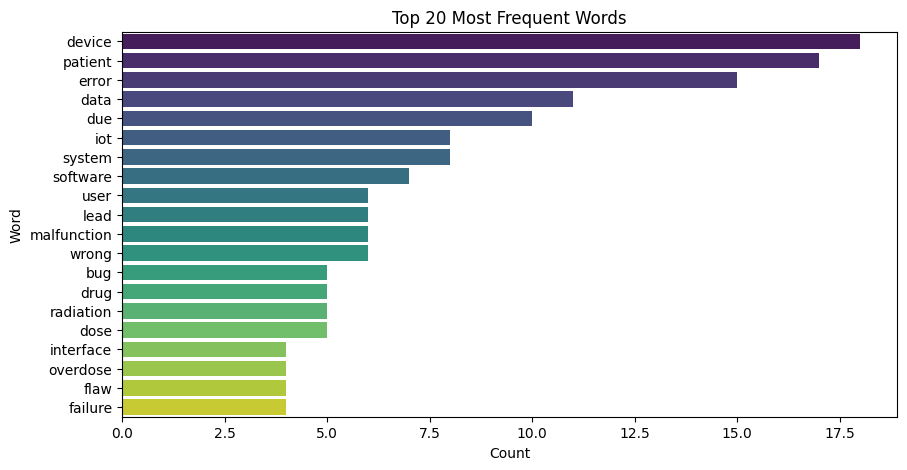

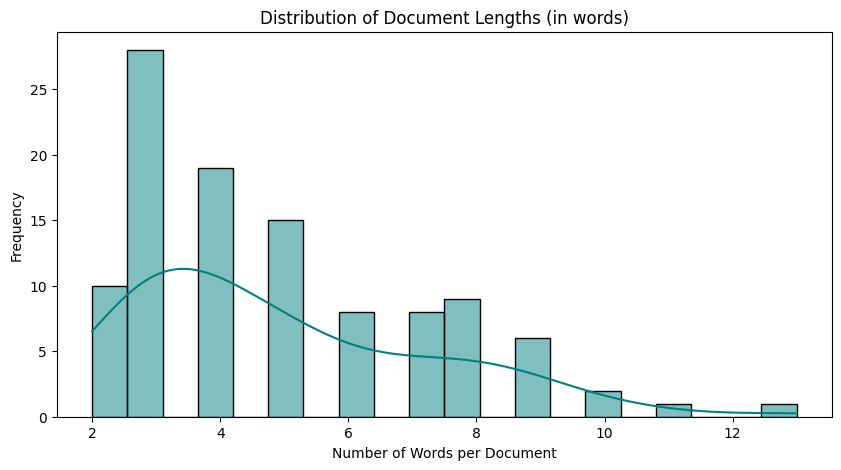

C:\Users\dell\AppData\Local\Temp\ipykernel_16368\1063056502.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(pos_tags), y=list(pos_freqs), palette="coolwarm")


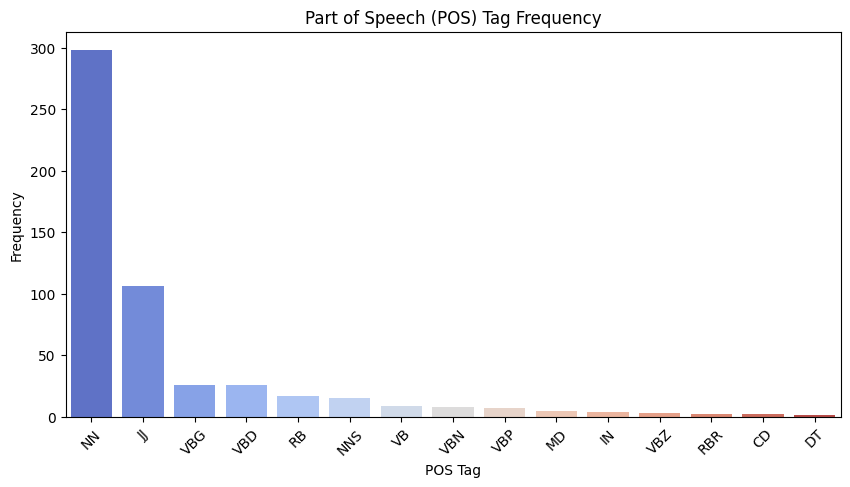

C:\Users\dell\AppData\Local\Temp\ipykernel_16368\1063056502.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bigram_counts, y=bigram_labels, palette="magma")


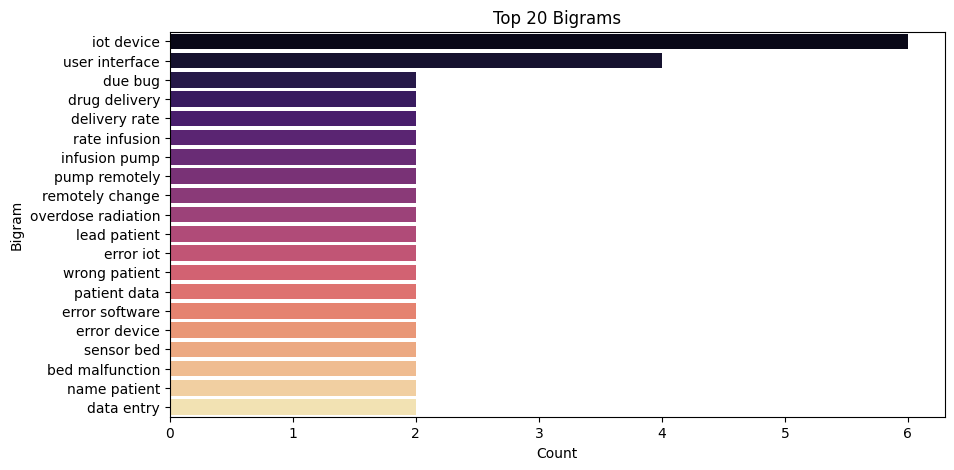

In [10]:
eda_nlp_analysis(X_text=X, num_words=100, top_n_words=20)

In [11]:
def Lightweight_RoBERT_feature_extraction(texts, model_name='sentence-transformers/all-MiniLM-L6-v2'):
    """Extract Lightweight_RoBERT features from texts."""
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)

    encoded_input = tokenizer(texts, padding=True, truncation=True, return_tensors='pt')
    with torch.no_grad():
        model_output = model(**encoded_input)

    token_embeddings = model_output.last_hidden_state
    attention_mask = encoded_input['attention_mask']
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()

    sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, dim=1)
    sum_mask = input_mask_expanded.sum(dim=1)
    embeddings = sum_embeddings / sum_mask

    X = embeddings.cpu().numpy()
    return X, model


In [12]:
def feature_extraction(X_text, method='Lightweight_RoBERT', model_dir='model', is_train=True):
    """
    Extract features from X_text using Lightweight RoBERTa model from Sentence-Transformers.
    - Train: Load from cache if available, else compute and save.
    - Test: Always compute, don't save.
    """
    if method != 'Lightweight_RoBERT':
        raise ValueError(f"[ERROR] Only 'Lightweight_RoBERT' is supported in this version.")

    x_file = os.path.join(model_dir, f'X_{method}.pkl')

    print(f"[INFO] Feature extraction method: {method}, Train mode: {is_train}")
    model_name = 'sentence-transformers/all-distilroberta-v1'

    if is_train:
        if os.path.exists(x_file):
            print(f"[INFO] Loading cached Lightweight RoBERTa features from {x_file}")
            X = joblib.load(x_file)
        else:
            print("[INFO] Computing Lightweight RoBERTa features...")
            X, model = Lightweight_RoBERT_feature_extraction(X_text, model_name=model_name)
            joblib.dump(X, x_file)
    else:
        print("[INFO] Performing Lightweight RoBERTa feature extraction for testing...")
        X, model = Lightweight_RoBERT_feature_extraction(X_text, model_name=model_name)

    return X

In [13]:
features = feature_extraction(X, method='Lightweight_RoBERT',is_train=True)

[INFO] Feature extraction method: Lightweight_RoBERT, Train mode: True
[INFO] Loading cached Lightweight RoBERTa features from model\X_Lightweight_RoBERT.pkl


Loading existing SGDClassifier model...
SGD Classifier Accuracy  : 36.36
SGD Classifier Precision : 42.50
SGD Classifier Recall    : 47.32
SGD Classifier FScore    : 31.25
SGD Classifier Classification Report
SGD Classifier
              precision    recall  f1-score   support

  non-severe       0.35      0.88      0.50         8
      severe       0.50      0.07      0.12        14

    accuracy                           0.36        22
   macro avg       0.42      0.47      0.31        22
weighted avg       0.45      0.36      0.26        22




C:\Users\dell\Desktop\nlp\Medical Bug Severity\metrics_calculator.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.metrics_df = pd.concat([self.metrics_df, metrics_entry], ignore_index=True)
C:\Users\dell\Desktop\nlp\Medical Bug Severity\metrics_calculator.py:79: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.class_performance_dfs[str(category)] = pd.concat([self.class_performance_dfs[str(category)], class_entry], ignore_index=True)
C:\Users\dell\Desktop\nlp\Medical Bug Severity\met

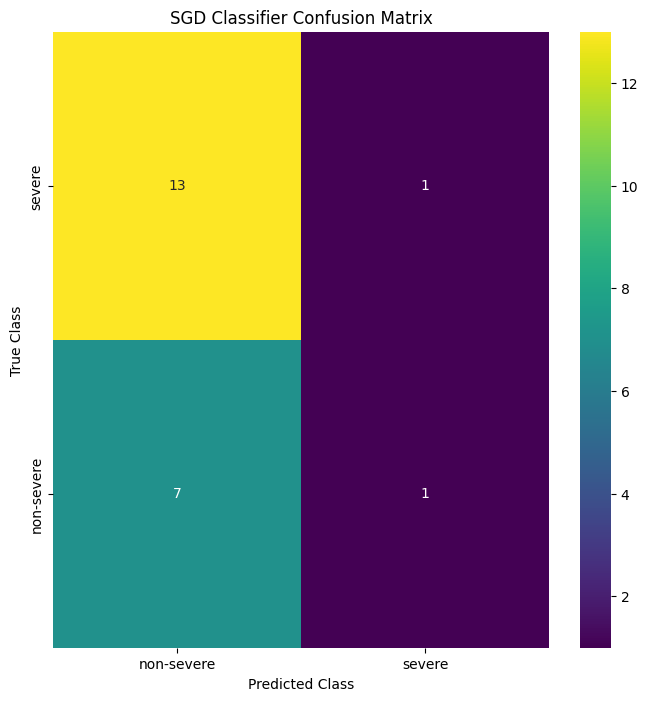

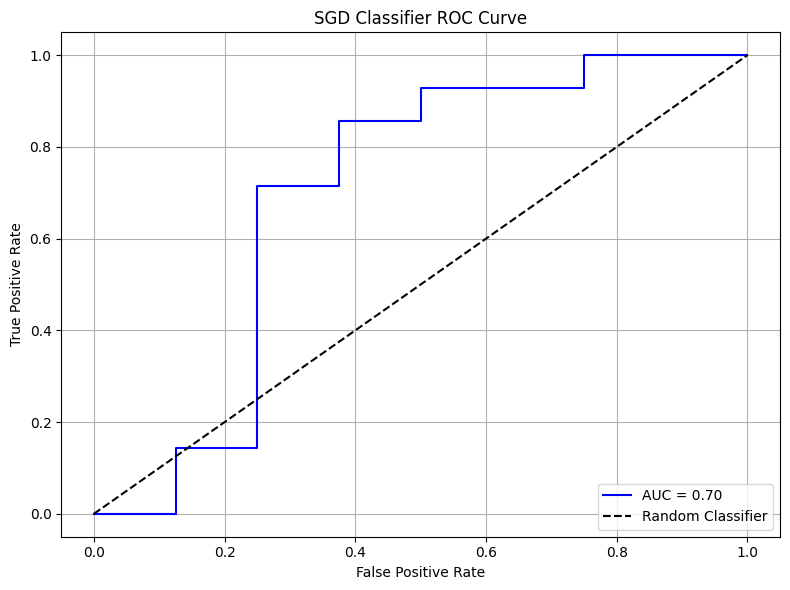

,loss,'hinge'
,penalty,'l2'
,alpha,1.0
,l1_ratio,0.15
,fit_intercept,True
,max_iter,5
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [ ]:
SGD_MODEL_PATH = "model/sgd_classifier.pkl"

def train_sgd_on_extracted_features(Algorithm, features, y_encoded):
    global sgd
    X_train, X_test, y_train, y_test = train_test_split(features, y_encoded, test_size=0.2, random_state=42)

    if os.path.exists(SGD_MODEL_PATH):
        print("Loading existing SGDClassifier model...")
        sgd = joblib.load(SGD_MODEL_PATH)
    else:
        print("Training SGDClassifier...")
        sgd = SGDClassifier(loss='hinge', max_iter=5, learning_rate='constant', eta0=1.0, alpha=1.0, random_state=42)
        sgd.fit(X_train, y_train)
        joblib.dump(sgd, SGD_MODEL_PATH)

    y_pred = sgd.predict(X_test)
    try:
        y_score = sgd.predict_proba(X_test)
    except AttributeError:
        y_score = expit(sgd.decision_function(X_test).reshape(-1, 1))  # sigmoid

    metrics_calculator.calculate_metrics(Algorithm, y_pred, y_test, y_score)
    return sgd

train_sgd_on_extracted_features("SGD Classifier", features, Y)

Loading existing NGBoost model...
NGBoost Classifier Accuracy  : 50.00
NGBoost Classifier Precision : 39.41
NGBoost Classifier Recall    : 41.96
NGBoost Classifier FScore    : 39.95
NGBoost Classifier Classification Report
NGBoost Classifier
              precision    recall  f1-score   support

  non-severe       0.20      0.12      0.15         8
      severe       0.59      0.71      0.65        14

    accuracy                           0.50        22
   macro avg       0.39      0.42      0.40        22
weighted avg       0.45      0.50      0.47        22




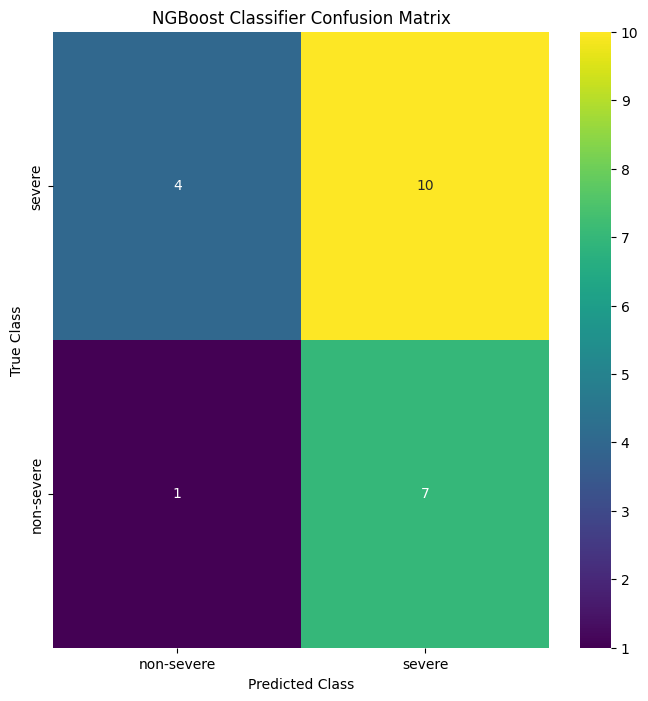

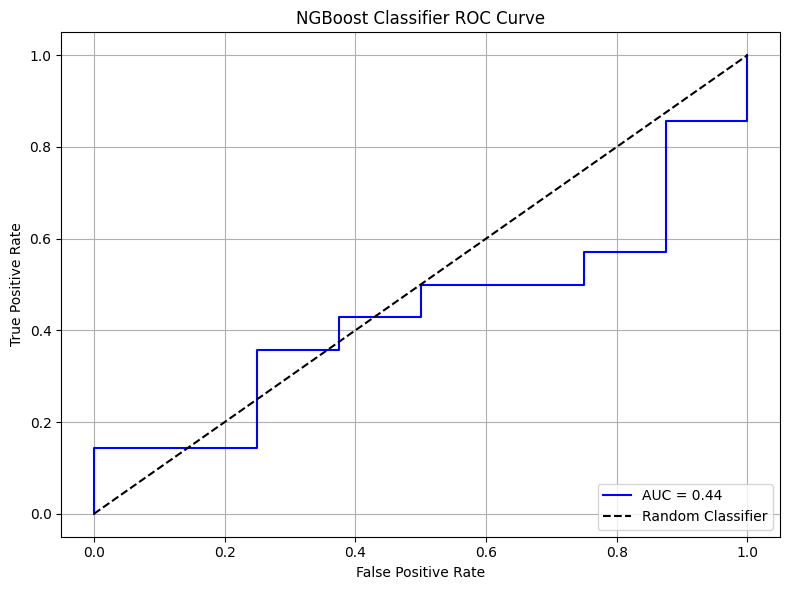

,Dist,<class 'ngboo....Categorical'>
,Score,<class 'ngboo...res.LogScore'>
,Base,"DecisionTreeR..., max_depth=3)"
,natural_gradient,False
,n_estimators,500
,learning_rate,0.01
,minibatch_frac,1.0
,col_sample,1.0
,verbose,True
,random_state,RandomState(M... 0x29DF0A67140
,validation_fraction,0.1


In [15]:
NGBOOST_MODEL_PATH = "model/ngboost_model.pkl"

def train_ngboost_on_extracted_features(Algorithm, features, y_encoded):
    global ngb
    X_train, X_test, y_train, y_test = train_test_split(features, y_encoded, test_size=0.2, random_state=42)

    if os.path.exists(NGBOOST_MODEL_PATH):
        print("Loading existing NGBoost model...")
        ngb = joblib.load(NGBOOST_MODEL_PATH)
    else:
        print("Training NGBoost classifier...")
        ngb = NGBClassifier(Dist=Bernoulli, natural_gradient=False, verbose=True)
        ngb.fit(X_train, y_train)
        joblib.dump(ngb, NGBOOST_MODEL_PATH)

    y_pred = ngb.predict(X_test)
    y_score = ngb.predict_proba(X_test)
    metrics_calculator.calculate_metrics(Algorithm, y_pred, y_test, y_score)
    return ngb

train_ngboost_on_extracted_features("NGBoost Classifier", features, Y)

In [16]:
def plot_training_history(history):
    
    plt.figure(figsize=(12, 5))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(history['accuracy'], label='Train Accuracy')
    plt.plot(history['val_accuracy'], label='Val Accuracy')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(history['loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()


In [17]:
def train_dense_RoBERT_classifier_extract_features(X, y):
    """
    Train a dense neural network on RoBERT features and extract mid-layer features.
    If model files exist, load them. Else, train and save the model, features, labels, and history.
    """
    if all(os.path.exists(p) for p in [DENSE_MODEL_PATH, FEATURE_PATH, HISTORY_PATH]):
        print("✅ [LOAD] Model and features found. Loading...")
        model = load_model(DENSE_MODEL_PATH)
        features = np.load(FEATURE_PATH)
        history = np.load(HISTORY_PATH, allow_pickle=True).item()
        return features

    print("🚀 [TRAIN] No saved model found. Training new Dense model...")

    # Use existing encoded labels
    num_classes = len(np.unique(y))
    y_categorical = to_categorical(y, num_classes=num_classes)

    # Build deeper model
    input_layer = Input(shape=(X.shape[1],))
    x = Dense(512, activation='relu')(input_layer)
    x = Dense(256, activation='relu')(x)
    x = Dense(128, activation='relu', name='feature_layer')(x)
    x = Dense(64, activation='relu')(x)
    output_layer = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # Train model
    history = model.fit(
        X, y_categorical,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        verbose=1
    )

    # Extract mid-layer features
    feature_extractor = Model(inputs=model.input, outputs=model.get_layer('feature_layer').output)
    features = feature_extractor.predict(X)

    # Save everything
    model.save(DENSE_MODEL_PATH)
    np.save(FEATURE_PATH, features)
    np.save(HISTORY_PATH, history.history)

    print("💾 Model, features, labels, and training history saved.")


    return features

In [18]:
MODEL_DIR = "model"
DENSE_MODEL_PATH = os.path.join(MODEL_DIR, "dense_feature_model.h5")
FEATURE_PATH = os.path.join(MODEL_DIR, "extracted_features.npy")
HISTORY_PATH = os.path.join(MODEL_DIR, "sbert_history.npy")
os.makedirs(MODEL_DIR, exist_ok=True)

In [19]:
features1 = train_dense_RoBERT_classifier_extract_features(features, Y)

✅ [LOAD] Model and features found. Loading...


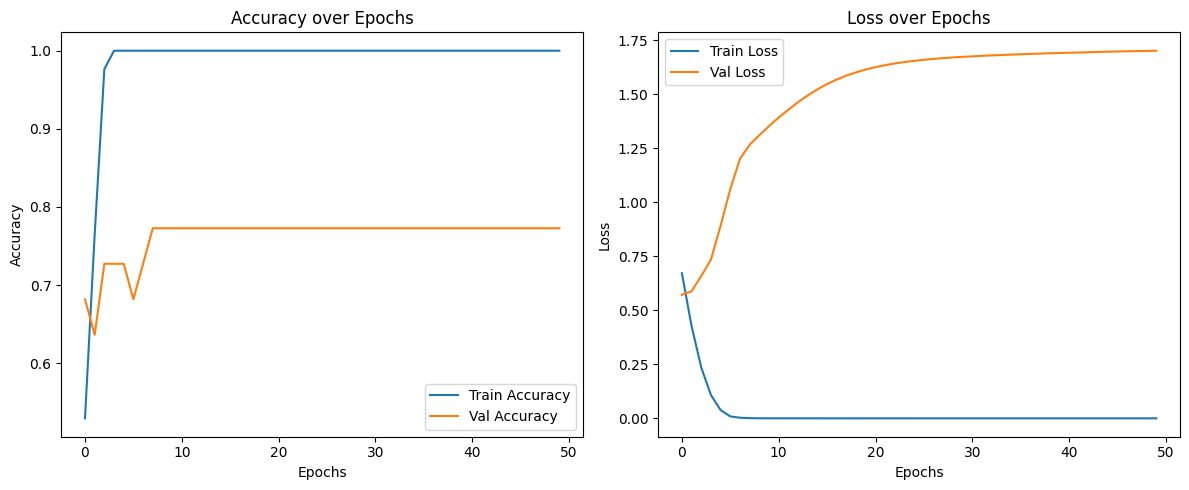

In [20]:
history = np.load(HISTORY_PATH, allow_pickle=True).item()
plot_training_history(history)

Loading existing SGDClassifier model...
DNN with SGD Classifier Accuracy  : 36.36
DNN with SGD Classifier Precision : 18.18
DNN with SGD Classifier Recall    : 50.00
DNN with SGD Classifier FScore    : 26.67
DNN with SGD Classifier Classification Report
DNN with SGD Classifier
              precision    recall  f1-score   support

  non-severe       0.36      1.00      0.53         8
      severe       0.00      0.00      0.00        14

    accuracy                           0.36        22
   macro avg       0.18      0.50      0.27        22
weighted avg       0.13      0.36      0.19        22




C:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

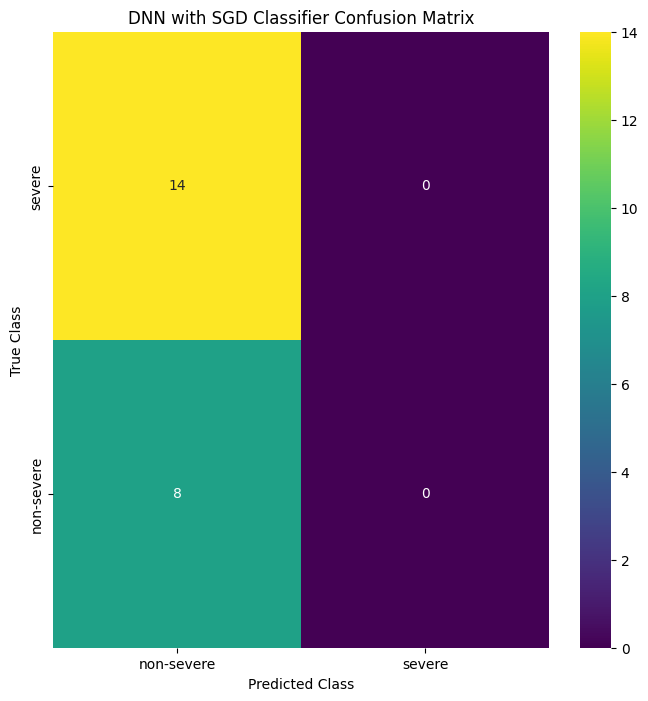

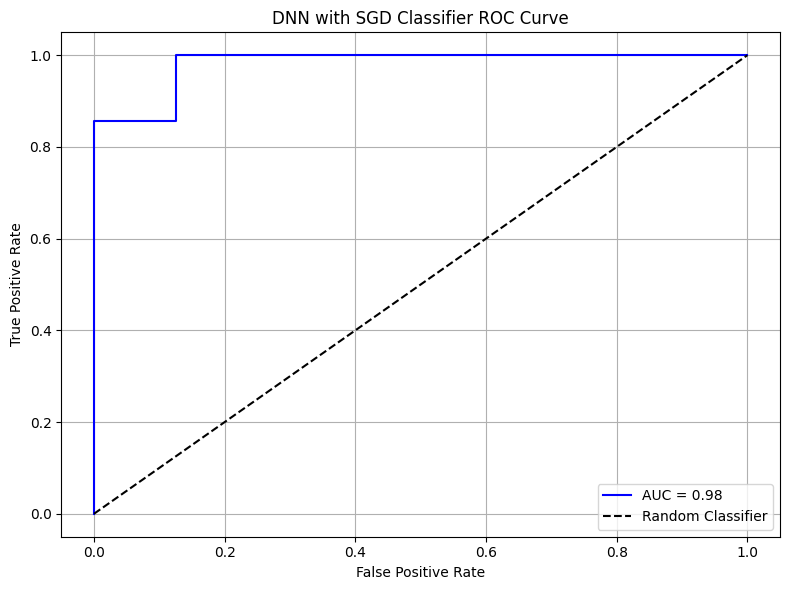

,loss,'hinge'
,penalty,'l2'
,alpha,1.0
,l1_ratio,0.15
,fit_intercept,True
,max_iter,5
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [21]:
SGD_MODEL_PATH = "model/sgd_dnn_classifier1.pkl"
train_sgd_on_extracted_features("DNN with SGD Classifier", features1, Y)

Loading existing NGBoost model...
DNN with NGBoost Classifier Accuracy  : 95.45
DNN with NGBoost Classifier Precision : 96.67
DNN with NGBoost Classifier Recall    : 93.75
DNN with NGBoost Classifier FScore    : 94.94
DNN with NGBoost Classifier Classification Report
DNN with NGBoost Classifier
              precision    recall  f1-score   support

  non-severe       1.00      0.88      0.93         8
      severe       0.93      1.00      0.97        14

    accuracy                           0.95        22
   macro avg       0.97      0.94      0.95        22
weighted avg       0.96      0.95      0.95        22




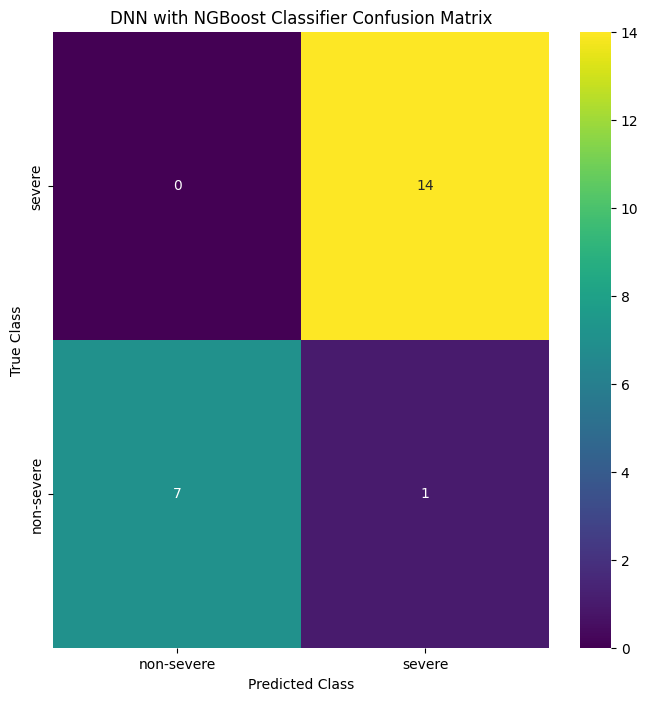

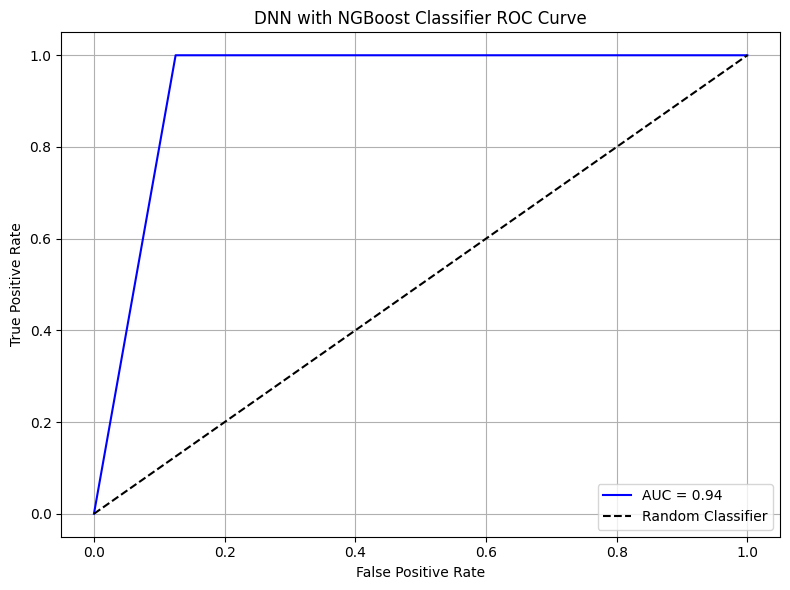

In [22]:
NGBOOST_MODEL_PATH = "model/ngboost_dnn_model1.pkl"
ng_final=train_ngboost_on_extracted_features("DNN with NGBoost Classifier", features1, Y)

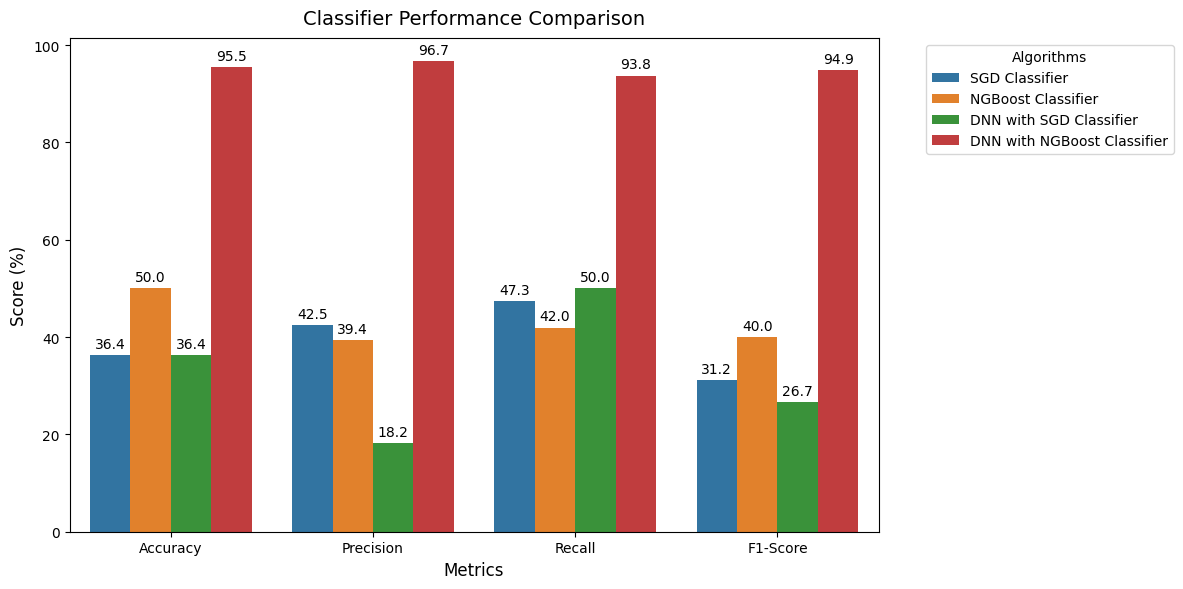

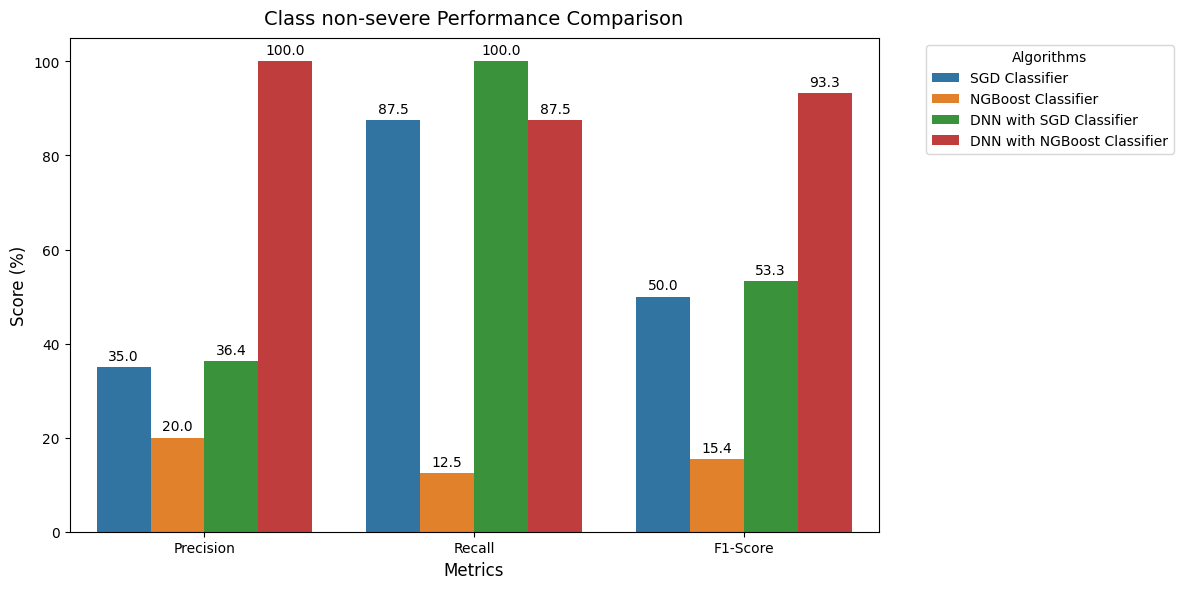

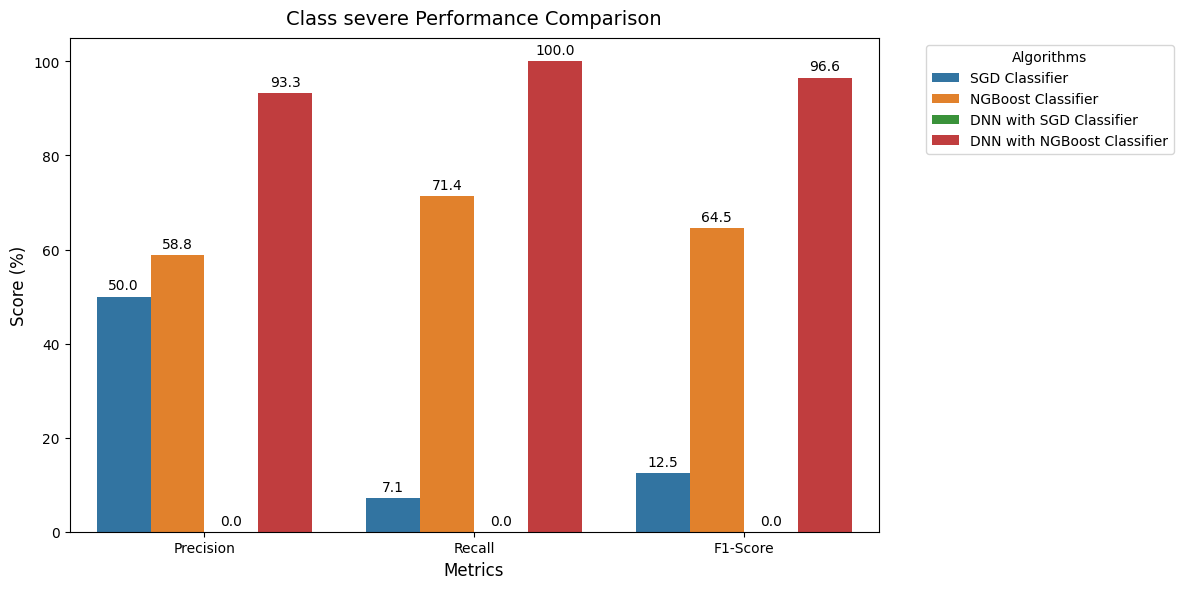

In [23]:
graph_plotter = GraphPlotter(metrics_calculator.metrics_df, metrics_calculator.class_performance_dfs)
graph_plotter.plot_all()

In [24]:
melted_df_new = metrics_calculator.metrics_df[['Algorithm', 'Accuracy', 'Precision', 'Recall', 'F1-Score']].copy()
melted_df_new = melted_df_new.round(3)
melted_df_new

,Algorithm,Accuracy,Precision,Recall,F1-Score
0,SGD Classifier,36.364,42.500,47.321,31.250
1,NGBoost Classifier,50.000,39.412,41.964,39.950
2,DNN with SGD Classifier,36.364,18.182,50.000,26.667
3,DNN with NGBoost Classifier,95.455,96.667,93.750,94.943


In [25]:
def test_extract_features_from_dense_model(X_test, model_path="dense_feature_model.h5"):
    print(f"✅ Loading model from: {model_path}")
    model = load_model(model_path)

    # Extract output from the intermediate 'feature_layer'
    feature_extractor = Model(inputs=model.input,
                              outputs=model.get_layer("feature_layer").output)

    print("🚀 Extracting features from test data...")
    features_test = feature_extractor.predict(X_test)

    return features_test

In [26]:
## Test Prediction

In [27]:
import pandas as pd
import numpy as np

# Declare sentence outside
sentence_text = "Lack of interoperability in IOT devices"

# Create DataFrame
df = pd.DataFrame({
    "Short Descritpion": [sentence_text]
})
	

In [28]:
df_test,_ = preprocess_data(df)
df_test

Preprocessing data (no saving)


['lack interoperability iot device']

In [29]:
features_test = feature_extraction(df_test,method='Lightweight_RoBERT',is_train=None)

[INFO] Feature extraction method: Lightweight_RoBERT, Train mode: None
[INFO] Performing Lightweight RoBERTa feature extraction for testing...


tokenizer_config.json:   0%|          | 0.00/333 [00:00<?, ?B/s]

C:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\dell\.cache\huggingface\hub\models--sentence-transformers--all-distilroberta-v1. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/653 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/328M [00:00<?, ?B/s]

In [30]:
features_test = test_extract_features_from_dense_model(features_test, DENSE_MODEL_PATH)

✅ Loading model from: model\dense_feature_model.h5
🚀 Extracting features from test data...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step


In [31]:
y_pred = ng_final.predict(features_test)

In [32]:
y_labels = le.inverse_transform(y_pred)

In [33]:
y_labels

array(['severe'], dtype=object)

In [34]:
### Batch Prediction

In [ ]:
test_path=r"Testdata.csv"
df_test1= upload_dataset(test_path)
df_test,_ = preprocess_data(df_test1)
df_test

Preprocessing data (no saving)


['crash exit reloading pgae',
 'user interface working due bug',
 'lack interoperability iot device',
 'network protocol embedded device',
 'memory management bug',
 'malicious activity happen due bug',
 'drug delivery rate infusion pump remotely change',
 'machine massively overdosed killed patient',
 'information leak severity rank',
 'device battery failed hold charge shortened runtime stopped unexpectedly',
 'cyberattack crash system',
 'overdose radiation lead patient death',
 'malfunction occurs runtime error iot device',
 'buffer overrun null pointer dereferences race condition resource memory leak',
 'surgical error due equipment failure',
 'system could incorrectly double dosage radiation',
 'camcer patient received overdose medicine due system fault',
 'miscalculates proper dosage radiation patient undergoing radiation therapy',
 'complex device lead incorrect result',
 'system parameter impact fucntion',
 'software code might impact reliability performance device',
 'device 

In [36]:
features_test = feature_extraction(df_test,method='Lightweight_RoBERT',is_train=None)

[INFO] Feature extraction method: Lightweight_RoBERT, Train mode: None
[INFO] Performing Lightweight RoBERTa feature extraction for testing...


In [37]:
y_pred = ng_final.predict(features_test)

In [38]:
y_labels = le.inverse_transform(y_pred)

In [39]:
df_result = df_test1.copy()
df_result['Predicted_Label'] = y_labels
df_result

,processed_Short Descritpion,Predicted_Label
0,crash exit reloading pgae,severe
1,user interface working due bug,non-severe
2,lack interoperability iot device,non-severe
3,network protocol embedded device,non-severe
4,memory management bug,non-severe
5,malicious activity happen due bug,non-severe
6,drug delivery rate infusion pump remotely change,non-severe
7,machine massively overdosed killed patient,severe
8,information leak severity rank,non-severe
9,device battery failed hold charge shortened ru...,non-severe
